# DAY 7 - Data Cleaning: Real-World Messy Data

**80% of a data analyst's job is cleaning data.**

Real data is always dirty:
- Missing values
- Duplicates
- Wrong data types
- Inconsistent formats
- Typos and garbage values
- Outliers

---

## Topics Covered
1. Creating Realistic Messy Data
2. Finding Problems (Audit)
3. Handling Missing Values (5 strategies)
4. Removing Duplicates
5. Fixing Data Types
6. String Cleaning
7. Outlier Detection & Treatment
8. Data Standardization
9. Feature Engineering
10. Saving Clean Data

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print('Libraries loaded!')

Libraries loaded!


---
## 1. Create Realistic Messy Data

In [34]:
# This is what real data looks like — messy!
np.random.seed(42)

raw_data = {
    'emp_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
               101, 112, 113, 114, 115],          # 101 is duplicate
    'name': ['Alice', 'bob', '  Charlie  ', 'DIANA', 'Eve',
              'frank', 'Grace', None, 'Henry', 'Iris',
              'Alice', 'Jake', 'karen', ' Leo ', 'Mia'],
    'age': [25, 30, 35, 28, -5, 150, 32, 27, 29, 31,
            25, 26, 33, 34, None],               # -5 and 150 = outliers
    'salary': [50000, 60000, None, 80000, 45000, 70000, None, 55000, 62000, 75000,
               50000, 48000, 66000, None, 72000],
    'department': ['IT', 'HR', 'it', 'Finance', 'HR', 'It', 'Finance', 'IT', 'HR', 'Finance',
                   'IT', 'hr', 'IT', 'Finance', 'HR'],  # inconsistent case
    'join_date': ['2020-01-15', '2019-03-22', '15/06/2021', '2018-11-30', '22-08-2022',
                  '2021-07-01', '2020/05/14', '2019-09-10', '2023-02-18', '2020-12-05',
                  '2020-01-15', '2022-04-25', '2019/11/08', '2021-03-17', '2020-06-30'],
    'email': ['alice@company.com', 'BOB@company.com', 'charlie@company.com', 'Diana@company.COM',
              'eve@company.com', 'frank@company.com', 'Grace@company.com', 'Henry@company.com',
              'invalid-email', 'dfgdgfd', 'alice@company.com', 'jake@company.com',
              'karen@company.com', 'leo@company.com', 'mia@company.com'],
    'phone': ['9876543210', '9123456789', 'N/A', '9876543210', '9234567890',
              '91-9345678901', '9456789012', '9567890123', '0000000000', '9678901234',
              '9876543210', '9789012345', '9890123456', None, '9012345678']
}

df_raw = pd.DataFrame(raw_data)
print('Raw Data:')
print(df_raw)
print(f'\nShape: {df_raw.shape}')

Raw Data:
    emp_id         name    age   salary department   join_date                email          phone
0      101        Alice   25.0  50000.0         IT  2020-01-15    alice@company.com     9876543210
1      102          bob   30.0  60000.0         HR  2019-03-22      BOB@company.com     9123456789
2      103    Charlie     35.0      NaN         it  15/06/2021  charlie@company.com            N/A
3      104        DIANA   28.0  80000.0    Finance  2018-11-30    Diana@company.COM     9876543210
4      105          Eve   -5.0  45000.0         HR  22-08-2022      eve@company.com     9234567890
5      106        frank  150.0  70000.0         It  2021-07-01    frank@company.com  91-9345678901
6      107        Grace   32.0      NaN    Finance  2020/05/14    Grace@company.com     9456789012
7      108         None   27.0  55000.0         IT  2019-09-10    Henry@company.com     9567890123
8      109        Henry   29.0  62000.0         HR  2023-02-18        invalid-email     0000000000


---
## 2. Step 1: Data Audit — Find All Problems

In [35]:
print('='*60)
print('DATA AUDIT REPORT')
print('='*60)

print(f'\nShape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')

print('\nColumn Info:')
df_raw.info()


DATA AUDIT REPORT

Shape: 15 rows x 8 columns

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   emp_id      15 non-null     int64  
 1   name        14 non-null     object 
 2   age         14 non-null     float64
 3   salary      12 non-null     float64
 4   department  15 non-null     object 
 5   join_date   15 non-null     object 
 6   email       15 non-null     object 
 7   phone       14 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 1.1+ KB


In [36]:

print('\nMissing Values:')
missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0])



Missing Values:
        Missing Count  Missing %
name                1        6.7
age                 1        6.7
salary              3       20.0
phone               1        6.7


In [37]:

print(f'\nDuplicate Rows: {df_raw.duplicated().sum()}')
print(f'Duplicate emp_id: {df_raw["emp_id"].duplicated().sum()}')


Duplicate Rows: 1
Duplicate emp_id: 1


In [38]:
print('Unique departments (before cleaning):')
print(df_raw['department'].unique())

print('\nAge range:', df_raw['age'].min(), 'to', df_raw['age'].max())
print('Salary stats:')
print(df_raw['salary'].describe())

Unique departments (before cleaning):
['IT' 'HR' 'it' 'Finance' 'It' 'hr']

Age range: -5.0 to 150.0
Salary stats:
count       12.000000
mean     61083.333333
std      11634.262358
min      45000.000000
25%      50000.000000
50%      61000.000000
75%      70500.000000
max      80000.000000
Name: salary, dtype: float64


---
## 3. Step 2: Handle Missing Values

5 Strategies:
1. Drop rows (when very few are missing)
2. Fill with mean/median (for numbers)
3. Fill with mode (for categories)
4. Fill with constant/placeholder
5. Forward/Backward fill (for time series)

In [39]:
df = df_raw.copy()  # Always work on a copy!

# Strategy 1: Fill numeric with median (robust to outliers)
df['salary'] = df['salary'].fillna(df['salary'].median())
print('Salary missing filled with median:', df['salary'].median())

# Strategy 2: Fill numeric with mean
age_mean = df['age'].mean()
df['age_temp'] = df['age'].fillna(age_mean)
print(f'Age missing: fill with mean = {age_mean:.1f}')

# Strategy 3: Drop rows where name is missing (critical field)
before_drop = len(df)
df = df.dropna(subset=['name'])
print(f'Rows before dropping null names: {before_drop}')
print(f'Rows after dropping null names : {len(df)}')

print('\nRemaining missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Salary missing filled with median: 61000.0
Age missing: fill with mean = 35.7
Rows before dropping null names: 15
Rows after dropping null names : 14

Remaining missing values:
age      1
phone    1
dtype: int64


---
## 4. Step 3: Remove Duplicates

## Removing Duplicate Records

### What is this?

Duplicate records are rows that appear more than once in a dataset. These duplicates can cause incorrect analysis and misleading results.

In this example, we identify duplicate rows and then remove duplicate employee records based on the `emp_id` column.

### Code Explanation

#### Display the number of rows before removing duplicates

```python
print('Before removing duplicates:', len(df))

In [40]:
print('Before removing duplicates:', len(df))
print('Duplicate rows:')
print(df[df.duplicated(keep=False)])

# Remove duplicate emp_id — keep first occurrence
df = df.drop_duplicates(subset=['emp_id'], keep='first')
print(f'\nAfter removing duplicates: {len(df)}')

Before removing duplicates: 14
Duplicate rows:
    emp_id   name   age   salary department   join_date              email       phone  age_temp
0      101  Alice  25.0  50000.0         IT  2020-01-15  alice@company.com  9876543210      25.0
10     101  Alice  25.0  50000.0         IT  2020-01-15  alice@company.com  9876543210      25.0

After removing duplicates: 13


---
## 5. Step 4: Fix Inconsistent Text Data

## Cleaning Text Data

This code cleans and standardizes the **name**, **department**, and **email** columns.

* **Name Column:** Removes extra spaces using `strip()` and converts names to Title Case using `title()`.
* **Department Column:** Removes extra spaces, standardizes department names, and converts them to a consistent format.
* **Email Column:** Converts emails to lowercase, removes extra spaces, and validates email formats using a regular expression (Regex).
* A new column `email_valid` is created where:

  * `True` = Valid email address
  * `False` = Invalid email address
* Finally, all records with invalid email addresses are displayed for review.

### Key Functions Used

* `strip()` → Removes leading and trailing spaces.
* `title()` → Converts text to Title Case.
* `upper()` → Converts text to uppercase.
* `lower()` → Converts text to lowercase.
* `replace()` → Standardizes values.
* `str.contains()` → Checks whether email addresses match a valid format.


In [41]:
# Clean NAME column
df['name'] = (
    df['name']
    .str.strip()        # Remove leading/trailing spaces
    .str.title()        # Title Case (Alice, Bob)
)

print('Names cleaned:')
print(df['name'].tolist())


Names cleaned:
['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace', 'Henry', 'Iris', 'Jake', 'Karen', 'Leo', 'Mia']


In [42]:

df['department']

0          IT
1          HR
2          it
3     Finance
4          HR
5          It
6     Finance
8          HR
9     Finance
11         hr
12         IT
13    Finance
14         HR
Name: department, dtype: object

In [43]:
# Clean DEPARTMENT column
df['department'] = (
    df['department']
    .str.strip()
    .str.upper()
    .replace({'IT': 'IT', 'HR': 'HR', 'FINANCE': 'Finance'})
)


In [44]:
print(df['department'])

0          IT
1          HR
2          IT
3     Finance
4          HR
5          IT
6     Finance
8          HR
9     Finance
11         HR
12         IT
13    Finance
14         HR
Name: department, dtype: object


In [45]:
print('\nDepartments after cleaning:')
print(df['department'].unique())



Departments after cleaning:
['IT' 'HR' 'Finance']


In [46]:

df['email']

0       alice@company.com
1         BOB@company.com
2     charlie@company.com
3       Diana@company.COM
4         eve@company.com
5       frank@company.com
6       Grace@company.com
8           invalid-email
9                 dfgdgfd
11       jake@company.com
12      karen@company.com
13        leo@company.com
14        mia@company.com
Name: email, dtype: object

In [47]:
# Clean EMAIL column
df['email'] = df['email'].str.strip().str.lower()
df['email']


0       alice@company.com
1         bob@company.com
2     charlie@company.com
3       diana@company.com
4         eve@company.com
5       frank@company.com
6       grace@company.com
8           invalid-email
9                 dfgdgfd
11       jake@company.com
12      karen@company.com
13        leo@company.com
14        mia@company.com
Name: email, dtype: object

In [48]:
df['email_valid'] = df['email'].str.contains(r'^[\w.-]+@[\w.-]+\.\w+$', regex=True)
print('\nInvalid emails:')
print(df[~df['email_valid']][['name', 'email']])


Invalid emails:
    name          email
8  Henry  invalid-email
9   Iris        dfgdgfd


## Cleaning Phone Numbers

This code cleans and standardizes the **phone** column.

* A custom function `clean_phone()` is created to process each phone number.
* Missing values (`NaN`), `'N/A'`, and `'0000000000'` are treated as invalid and replaced with `None`.
* Hyphens (`-`) and spaces are removed from phone numbers.
* If a phone number starts with the Indian country code `91`, it is removed.
* Only valid 10-digit phone numbers are kept.
* Invalid phone numbers are replaced with `None`.
* The cleaned phone numbers are then displayed along with employee names.

### Key Functions Used

* `pd.isna()` → Checks for missing values.
* `replace()` → Removes unwanted characters.
* `startswith()` → Checks if a number begins with a specific value.
* `apply()` → Applies the cleaning function to every row in the column.


In [49]:
# Clean PHONE column
def clean_phone(phone):
    if pd.isna(phone) or phone in ['N/A', '0000000000']:
        return None
    cleaned = str(phone).replace('-', '').replace(' ', '')
    if cleaned.startswith('91') and len(cleaned) == 12:
        cleaned = cleaned[2:]
    return cleaned if len(cleaned) == 10 else None

df['phone'] = df['phone'].apply(clean_phone)
print('Phone numbers cleaned:')
print(df[['name', 'phone']])

Phone numbers cleaned:
       name       phone
0     Alice  9876543210
1       Bob  9123456789
2   Charlie        None
3     Diana  9876543210
4       Eve  9234567890
5     Frank  9345678901
6     Grace  9456789012
8     Henry        None
9      Iris  9678901234
11     Jake  9789012345
12    Karen  9890123456
13      Leo        None
14      Mia  9012345678


---
## 6. Step 5: Fix Data Types + Date Parsing

## Converting Dates to Datetime Format

This code converts the **join_date** column into a proper datetime format.

* `pd.to_datetime()` is used to convert date values into Pandas datetime objects.
* `infer_datetime_format=True` helps Pandas automatically recognize different date formats.
* `errors='coerce'` converts invalid or unrecognized dates into `NaT` (Not a Time) instead of generating an error.
* The cleaned dates are displayed to verify the conversion.
* Finally, the data type of the `join_date` column is checked to ensure it has been converted to `datetime`.

### Key Functions Used

* `pd.to_datetime()` → Converts values to datetime format.
* `infer_datetime_format=True` → Detects date formats automatically.
* `errors='coerce'` → Replaces invalid dates with `NaT`.
* `dtypes` → Displays the data type of a column.


In [50]:
# Convert join_date to proper datetime
# Multiple formats in the data — use format='mixed'
df['join_date'] = pd.to_datetime(df['join_date'], format='mixed', dayfirst=False, errors='coerce')
print('Dates parsed:')
print(df[['name', 'join_date']])
print('\nData types after fixing:')
print(df[['join_date']].dtypes)

Dates parsed:
       name  join_date
0     Alice 2020-01-15
1       Bob 2019-03-22
2   Charlie 2021-06-15
3     Diana 2018-11-30
4       Eve 2022-08-22
5     Frank 2021-07-01
6     Grace 2020-05-14
8     Henry 2023-02-18
9      Iris 2020-12-05
11     Jake 2022-04-25
12    Karen 2019-11-08
13      Leo 2021-03-17
14      Mia 2020-06-30

Data types after fixing:
join_date    datetime64[ns]
dtype: object


## Extracting Date Features

This code extracts useful information from the **join_date** column.

* `join_year` stores the year in which the employee joined.
* `join_month` stores the month in which the employee joined.
* `tenure_years` calculates the employee's approximate years of service in the company.
* The tenure is calculated by finding the difference between today's date and the joining date.
* Finally, the extracted date features are displayed for analysis.

### Key Functions Used

* `.dt.year` → Extracts the year from a datetime column.
* `.dt.month` → Extracts the month from a datetime column.
* `pd.Timestamp('today')` → Returns the current date and time.
* `.dt.days` → Extracts the number of days from a time difference.


In [51]:
# Extract useful date parts
df['join_year']  = df['join_date'].dt.year
df['join_month'] = df['join_date'].dt.month
df['tenure_years'] = (pd.Timestamp('today') - df['join_date']).dt.days // 365

print('Date features extracted:')
print(df[['name', 'join_date', 'join_year', 'join_month', 'tenure_years']])

Date features extracted:
       name  join_date  join_year  join_month  tenure_years
0     Alice 2020-01-15       2020           1             6
1       Bob 2019-03-22       2019           3             7
2   Charlie 2021-06-15       2021           6             5
3     Diana 2018-11-30       2018          11             7
4       Eve 2022-08-22       2022           8             3
5     Frank 2021-07-01       2021           7             4
6     Grace 2020-05-14       2020           5             6
8     Henry 2023-02-18       2023           2             3
9      Iris 2020-12-05       2020          12             5
11     Jake 2022-04-25       2022           4             4
12    Karen 2019-11-08       2019          11             6
13      Leo 2021-03-17       2021           3             5
14      Mia 2020-06-30       2020           6             5


---
## 7. Step 6: Outlier Detection & Treatment

## Handling Age Outliers

This code identifies and fixes unrealistic values in the **age** column.

* First, the existing age values are displayed to check for outliers.
* Ages below **18** or above **65** are considered invalid based on domain knowledge.
* Invalid age values are replaced with `NaN`.
* Missing values are then filled using the **median age**, which is less affected by outliers.
* Finally, the cleaned age values are displayed.

### Key Functions Used

* `pd.notna()` → Checks if a value is not missing.
* `apply()` → Applies a function to each value in the column.
* `np.nan` → Represents missing values.
* `median()` → Calculates the middle value of the data.
* `fillna()` → Replaces missing values with a specified value.


In [52]:
# First, fix age — it has obvious outliers (-5, 150)
print('Age values:', df['age'].tolist())

# Method 1: Hard limits (domain knowledge)
df['age_clean'] = df['age'].apply(lambda x: x if (pd.notna(x) and 18 <= x <= 65) else np.nan)
df['age_clean'] = df['age_clean'].fillna(df['age_clean'].median())
print('\nAge after fixing outliers:')
print(df['age_clean'].tolist())

Age values: [25.0, 30.0, 35.0, 28.0, -5.0, 150.0, 32.0, 29.0, 31.0, 26.0, 33.0, 34.0, nan]

Age after fixing outliers:
[25.0, 30.0, 35.0, 28.0, 30.5, 30.5, 32.0, 29.0, 31.0, 26.0, 33.0, 34.0, 30.5]


## Detecting and Handling Salary Outliers using IQR

This code uses the **Interquartile Range (IQR)** method to identify salary outliers.

* `Q1` (25th percentile) and `Q3` (75th percentile) are calculated.
* `IQR` is found using: **IQR = Q3 - Q1**.
* Lower and upper bounds are calculated using the IQR rule:

  * Lower Bound = Q1 − 1.5 × IQR
  * Upper Bound = Q3 + 1.5 × IQR
* Salary values outside these bounds are considered outliers.
* All detected outliers are displayed.
* Instead of removing them, outlier salaries are capped using **Winsorization** with the `clip()` function.
* Finally, summary statistics of the cleaned salary data are displayed.

### Key Functions Used

* `quantile()` → Calculates percentiles.
* `describe()` → Displays summary statistics.
* `clip()` → Limits values within a specified range.
* Boolean filtering (`|`) → Identifies outlier records.


In [53]:
# Method 2: IQR method for salary
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Salary IQR Analysis:')
print(f'  Q1 = {Q1:,.0f}')
print(f'  Q3 = {Q3:,.0f}')
print(f'  IQR = {IQR:,.0f}')
print(f'  Lower Bound = {lower_bound:,.0f}')
print(f'  Upper Bound = {upper_bound:,.0f}')

outliers = df[(df['salary'] < lower_bound) | (df['salary'] > upper_bound)]
print(f'\nSalary Outliers ({len(outliers)} found):')
print(outliers[['name', 'salary']])

# Cap outliers (Winsorization)
df['salary'] = df['salary'].clip(lower=lower_bound, upper=upper_bound)
print('\nSalary after capping outliers:')
print(df['salary'].describe())

Salary IQR Analysis:
  Q1 = 60,000
  Q3 = 70,000
  IQR = 10,000
  Lower Bound = 45,000
  Upper Bound = 85,000

Salary Outliers (0 found):
Empty DataFrame
Columns: [name, salary]
Index: []

Salary after capping outliers:
count       13.000000
mean     62384.615385
std      10436.621911
min      45000.000000
25%      60000.000000
50%      61000.000000
75%      70000.000000
max      80000.000000
Name: salary, dtype: float64


## Visualizing Outliers Before and After Treatment

This code creates box plots to compare salary data before and after outlier treatment.

* Random salary data is generated using a normal distribution.
* A few extreme values (outliers) are added manually.
* `np.clip()` is used to cap extreme values within a specified range.
* Two box plots are created:

  * **Before Outlier Treatment** → Shows the original data with outliers.
  * **After Outlier Treatment** → Shows the data after capping outliers.
* This visual comparison helps understand the impact of outlier treatment on the dataset.

### Key Functions Used

* `np.random.normal()` → Generates random salary data.
* `np.concatenate()` → Combines arrays.
* `np.clip()` → Caps values within a range.
* `plt.subplots()` → Creates multiple plots.
* `boxplot()` → Visualizes data distribution and outliers.
* `plt.show()` → Displays the plots.


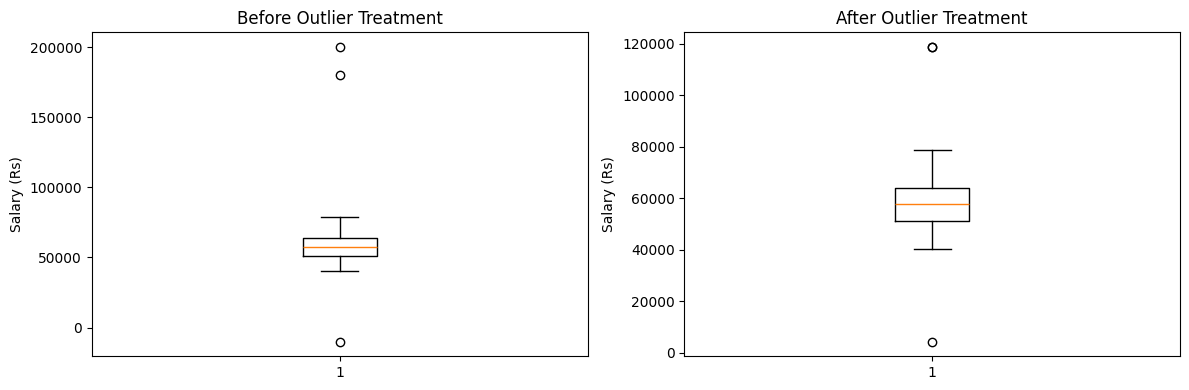

In [54]:
# Visualize outliers before vs after
np.random.seed(42)
orig = np.concatenate([np.random.normal(60000, 10000, 50), [200000, -10000, 180000]])
capped = np.clip(orig, orig.mean() - 2*orig.std(), orig.mean() + 2*orig.std())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(orig)
axes[0].set_title('Before Outlier Treatment')
axes[0].set_ylabel('Salary (Rs)')
axes[1].boxplot(capped)
axes[1].set_title('After Outlier Treatment')
axes[1].set_ylabel('Salary (Rs)')
plt.tight_layout()
plt.show()

---
## 8. Step 7: Feature Engineering

Creating new columns from existing ones.

## Feature Engineering

This code creates new features from existing data to make analysis more meaningful.

* A **salary_band** column is created to categorize employees as **Junior, Mid, Senior,** or **Lead** based on their salary.
* An **age_group** column is created using `pd.cut()` to group employees into age categories.
* A **first_name** column is extracted from the full name by taking the first word.
* These new features help simplify analysis and reporting.

### Key Functions Used

* `apply()` → Applies a custom function to each salary value.
* `pd.cut()` → Groups continuous values into categories.
* `str.split()` → Splits a string into parts.
* `str[0]` → Extracts the first element from the split result.


In [55]:
# 1. Salary band
def salary_band(sal):
    if sal < 50000: return 'Junior'
    elif sal < 70000: return 'Mid'
    elif sal < 90000: return 'Senior'
    else: return 'Lead'

df['salary_band'] = df['salary'].apply(salary_band)

# 2. Age group
df['age_group'] = pd.cut(
    df['age_clean'],
    bins=[0, 25, 35, 45, 100],
    labels=['Young (<=25)', 'Mid (26-35)', 'Experienced (36-45)', 'Senior (45+)']
)

# 3. First name from full name
df['first_name'] = df['name'].str.split().str[0]

print('Feature Engineering Results:')
print(df[['name', 'salary', 'salary_band', 'age_clean', 'age_group', 'first_name']])

Feature Engineering Results:
       name   salary salary_band  age_clean     age_group first_name
0     Alice  50000.0         Mid       25.0  Young (<=25)      Alice
1       Bob  60000.0         Mid       30.0   Mid (26-35)        Bob
2   Charlie  61000.0         Mid       35.0   Mid (26-35)    Charlie
3     Diana  80000.0      Senior       28.0   Mid (26-35)      Diana
4       Eve  45000.0      Junior       30.5   Mid (26-35)        Eve
5     Frank  70000.0      Senior       30.5   Mid (26-35)      Frank
6     Grace  61000.0         Mid       32.0   Mid (26-35)      Grace
8     Henry  62000.0         Mid       29.0   Mid (26-35)      Henry
9      Iris  75000.0      Senior       31.0   Mid (26-35)       Iris
11     Jake  48000.0      Junior       26.0   Mid (26-35)       Jake
12    Karen  66000.0         Mid       33.0   Mid (26-35)      Karen
13      Leo  61000.0         Mid       34.0   Mid (26-35)        Leo
14      Mia  72000.0      Senior       30.5   Mid (26-35)        Mia


## Encoding Categorical Data

This code converts the **department** column into numerical formats that can be used in Machine Learning models.

* **One-Hot Encoding** creates separate binary columns for each department.
* Each column contains `1` if the employee belongs to that department, otherwise `0`.
* **Label Encoding** assigns a unique numeric value to each department category.
* The encoded data can then be used as input for machine learning algorithms.

### Key Functions Used

* `pd.get_dummies()` → Performs One-Hot Encoding.
* `LabelEncoder()` → Converts categories into numeric labels.
* `fit_transform()` → Learns categories and converts them into numbers.
* `drop_duplicates()` → Displays unique department-encoding pairs.


In [56]:
import sys

print(sys.executable)
print(sys.version)

/opt/homebrew/opt/python@3.11/bin/python3.11
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]


In [57]:
import sys

!{sys.executable} -m pip show scikit-learn

In [58]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 3.9 MB/s  0:00:02 eta 0:00:01
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [59]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import pandas as pd

# 4. One-Hot Encoding
onehot = OneHotEncoder(sparse_output=False)

dept_encoded = pd.DataFrame(
    onehot.fit_transform(df[['department']]),
    columns=onehot.get_feature_names_out(['department']),
    index=df.index  # align with df index
)

print("Department Encoded (One-Hot Encoding):")
print(dept_encoded.head())

# 5. Ordinal Encoding
ordinal = OrdinalEncoder(dtype=int)

df['dept_encoded'] = ordinal.fit_transform(df[['department']])

print("\nDepartment Label Encoded:")
print(df[['department', 'dept_encoded']].drop_duplicates())

Department Encoded (One-Hot Encoding):
   department_Finance  department_HR  department_IT
0                 0.0            0.0            1.0
1                 0.0            1.0            0.0
2                 0.0            0.0            1.0
3                 1.0            0.0            0.0
4                 0.0            1.0            0.0

Department Label Encoded:
  department  dept_encoded
0         IT             2
1         HR             1
3    Finance             0


---
## 9. Step 8: Standardization & Normalization

## Feature Scaling

This code scales the **salary** column using two common techniques used in Machine Learning.

* **Min-Max Scaling** converts salary values to a range between **0 and 1**.
* **Standardization (Z-Score Scaling)** transforms salary values so that they have a mean of **0** and a standard deviation of **1**.
* Scaling helps machine learning algorithms perform better when features have different ranges.
* The original, normalized, and standardized salary values are displayed for comparison.

### Key Functions Used

* `MinMaxScaler()` → Scales values between 0 and 1.
* `StandardScaler()` → Performs Z-score standardization.
* `fit_transform()` → Learns scaling parameters and applies the transformation.
* `round()` → Rounds values to a specified number of decimal places.


In [65]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max Normalization (0 to 1)
scaler = MinMaxScaler()
df['salary_normalized'] = scaler.fit_transform(df[['salary']])

# Z-score Standardization (mean=0, std=1)
z_scaler = StandardScaler()
df['salary_standardized'] = z_scaler.fit_transform(df[['salary']])

print('Scaling Comparison:')
print(df[['salary', 'salary_normalized', 'salary_standardized']].round(3))

Scaling Comparison:
     salary  salary_normalized  salary_standardized
0   50000.0              0.143               -1.235
1   60000.0              0.429               -0.238
2   61000.0              0.457               -0.138
3   80000.0              1.000                1.757
4   45000.0              0.000               -1.734
5   70000.0              0.714                0.759
6   61000.0              0.457               -0.138
8   62000.0              0.486               -0.038
9   75000.0              0.857                1.258
11  48000.0              0.086               -1.435
12  66000.0              0.600                0.361
13  61000.0              0.457               -0.138
14  72000.0              0.771                0.959


---
## 10. Final Clean Dataset

## Creating the Final Clean Dataset

This code creates a final cleaned dataset by selecting only the required columns.

* A new DataFrame `df_clean` is created with important employee information.
* The column `age_clean` is renamed to `age` for simplicity.
* The final dataset is displayed along with its shape (rows and columns).
* Missing values in each column are checked using `isnull().sum()`.
* Finally, the cleaned dataset is saved as a CSV file named **employees_clean.csv**.

### Key Functions Used

* `rename()` → Renames column names.
* `shape` → Returns the number of rows and columns.
* `isnull().sum()` → Counts missing values in each column.
* `to_csv()` → Saves the DataFrame as a CSV file.


In [67]:
# Build final clean dataframe
df_clean = df[[
    'emp_id', 'name', 'department', 'age_clean', 'salary',
    'salary_band', 'age_group', 'tenure_years', 'join_year', 'email'
]].rename(columns={'age_clean': 'age'})

print('FINAL CLEAN DATASET:')
print(df_clean)
print(f'\nShape: {df_clean.shape}')
print('\nMissing values:')
print(df_clean.isnull().sum())

# Save to CSV
df_clean.to_csv('employees_clean.csv', index=False)
print('\nSaved to employees_clean.csv')

FINAL CLEAN DATASET:
    emp_id     name department   age   salary salary_band     age_group  tenure_years  join_year                email
0      101    Alice         IT  25.0  50000.0         Mid  Young (<=25)             6       2020    alice@company.com
1      102      Bob         HR  30.0  60000.0         Mid   Mid (26-35)             7       2019      bob@company.com
2      103  Charlie         IT  35.0  61000.0         Mid   Mid (26-35)             5       2021  charlie@company.com
3      104    Diana    Finance  28.0  80000.0      Senior   Mid (26-35)             7       2018    diana@company.com
4      105      Eve         HR  30.5  45000.0      Junior   Mid (26-35)             3       2022      eve@company.com
5      106    Frank         IT  30.5  70000.0      Senior   Mid (26-35)             4       2021    frank@company.com
6      107    Grace    Finance  32.0  61000.0         Mid   Mid (26-35)             6       2020    grace@company.com
8      109    Henry         HR  29.

---
## Data Cleaning Checklist

| Step | Action | Function |
|------|--------|----------|
| 1 | Check missing values | `df.isnull().sum()` |
| 2 | Check duplicates | `df.duplicated().sum()` |
| 3 | Check data types | `df.dtypes` |
| 4 | Fill missing numbers | `fillna(median/mean)` |
| 5 | Fill missing categories | `fillna(mode()[0])` |
| 6 | Drop duplicates | `drop_duplicates()` |
| 7 | Fix text case | `.str.strip().str.title()` |
| 8 | Parse dates | `pd.to_datetime()` |
| 9 | Fix outliers | IQR or domain knowledge |
| 10 | Create new features | Column operations |

---
## Homework

1. Create a messy dataset with 20 rows and 5 columns
2. Introduce missing values, duplicates, wrong types
3. Clean all issues step by step
4. Add 3 new feature-engineered columns
5. Save the clean version as CSV